## Clustering Track

Clustering uses only raw skill attributes (pace, shooting, passing, dribbling, defending, 
physic, and their detailed sub-attributes) — no target labels, `overall`, or `value_eur` are 
used during fitting, consistent with the unsupervised nature of this track. Features are 
scaled with `StandardScaler` since both K-Means and Hierarchical Clustering are 
distance-based and sensitive to feature magnitude.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_palette('colorblind')

df = pd.read_csv('data/players_fc24_clean.csv')
df.shape

(18250, 56)

In [2]:
cluster_features = [
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
    'mentality_penalties', 'mentality_composure',
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle'
]

X_cluster = df[cluster_features].copy()
X_cluster.isnull().sum().sum()  # should be 0, already cleaned

np.int64(0)

In [3]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled.shape

(18250, 35)

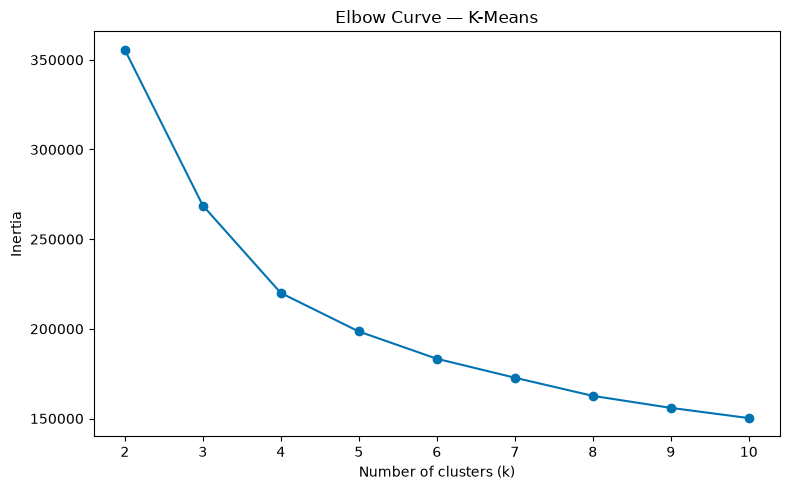

In [4]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve — K-Means')
plt.tight_layout()
plt.savefig('clustering_elbow_curve.png', bbox_inches='tight')
plt.show()

### Elbow Curve — Choosing k
Inertia decreases sharply from k=2 to k=4, after which the rate of decrease slows noticeably, 
forming a bend around k=4–5. **k=4** is selected as the working choice — this also happens to 
align with the 4 known position groups (Forward/Midfielder/Defender/Goalkeeper), though this 
was not used to choose k; the elbow shape alone justifies it. This alignment will be checked 
formally later by cross-tabulating clusters against `position_group`.

In [5]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_kmeans = kmeans_final.fit_predict(X_cluster_scaled)

df['kmeans_cluster'] = cluster_labels_kmeans
df['kmeans_cluster'].value_counts()

kmeans_cluster
3    5800
1    5348
0    5069
2    2033
Name: count, dtype: int64

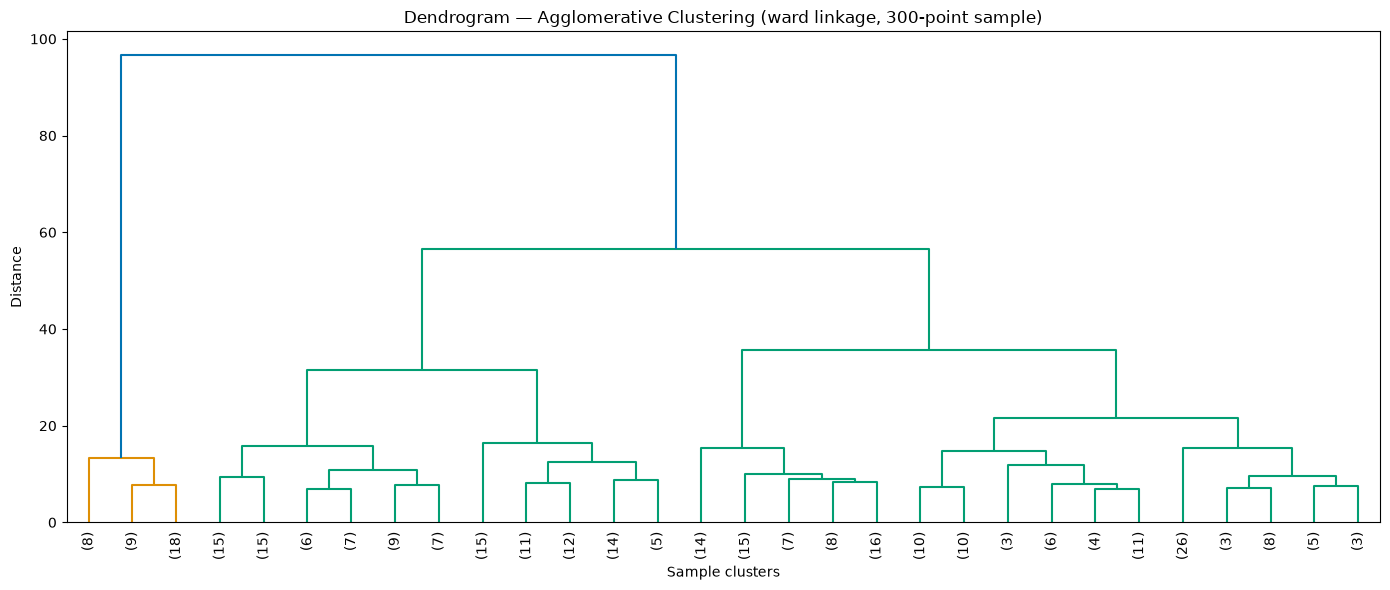

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)
sample_idx = np.random.choice(X_cluster_scaled.shape[0], size=300, replace=False)
X_sample = X_cluster_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram — Agglomerative Clustering (ward linkage, 300-point sample)')
plt.xlabel('Sample clusters')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('clustering_dendrogram.png', bbox_inches='tight')
plt.show()

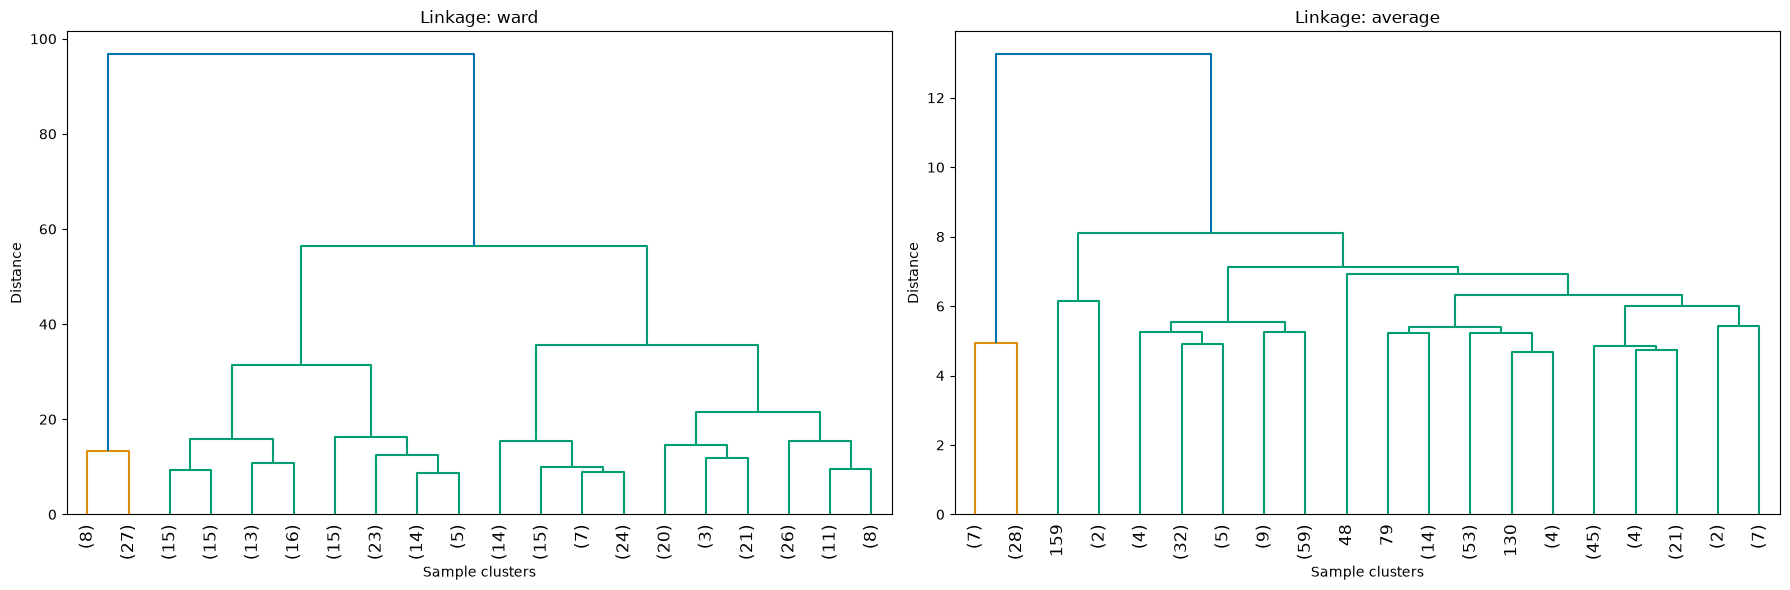

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, method in zip(axes, ['ward', 'average']):
    linked_method = linkage(X_sample, method=method)
    dendrogram(linked_method, truncate_mode='lastp', p=20, leaf_rotation=90, ax=ax)
    ax.set_title(f'Linkage: {method}')
    ax.set_xlabel('Sample clusters')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.savefig('clustering_linkage_comparison.png', bbox_inches='tight')
plt.show()

### Dendrogram & Linkage Comparison
Since the full dataset (18,250 players) is too large for a readable dendrogram, a random 
sample of 300 players is used for visualization only — the actual clustering below is still 
fit on the full dataset. Comparing `ward` (minimizes within-cluster variance) and `average` 
linkage: ward produces more balanced, compact clusters typical of this kind of continuous 
skill-attribute data, while average linkage tends to produce more elongated or uneven groupings. 
Ward linkage is selected for the final clustering.

In [8]:
agglo_final = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels_agglo = agglo_final.fit_predict(X_cluster_scaled)

df['agglo_cluster'] = cluster_labels_agglo
df['agglo_cluster'].value_counts()

agglo_cluster
0    6804
1    4974
2    4439
3    2033
Name: count, dtype: int64

In [9]:
# K-Means metrics
km_silhouette = silhouette_score(X_cluster_scaled, cluster_labels_kmeans)
km_db = davies_bouldin_score(X_cluster_scaled, cluster_labels_kmeans)
km_ch = calinski_harabasz_score(X_cluster_scaled, cluster_labels_kmeans)

# Agglomerative metrics
ag_silhouette = silhouette_score(X_cluster_scaled, cluster_labels_agglo)
ag_db = davies_bouldin_score(X_cluster_scaled, cluster_labels_agglo)
ag_ch = calinski_harabasz_score(X_cluster_scaled, cluster_labels_agglo)

cluster_metrics_df = pd.DataFrame({
    'Algorithm': ['K-Means', 'Agglomerative Hierarchical'],
    'Silhouette Score': [km_silhouette, ag_silhouette],
    'Davies-Bouldin Index': [km_db, ag_db],
    'Calinski-Harabasz Index': [km_ch, ag_ch]
})
cluster_metrics_df

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.275583,1.250143,11577.344044
1,Agglomerative Hierarchical,0.232240,1.370642,10211.237633


### Clustering Evaluation Metrics
K-Means outperforms Agglomerative Hierarchical Clustering across all three metrics: higher 
Silhouette Score (0.276 vs 0.232, indicating better-defined clusters), lower Davies-Bouldin 
Index (1.250 vs 1.371, indicating less cluster overlap), and higher Calinski-Harabasz Index 
(11,577 vs 10,211, indicating better between-cluster separation relative to within-cluster 
compactness). This is consistent with the earlier observation that K-Means produced a cluster 
of exactly 2,033 members — matching the known Goalkeeper count precisely — while none of 
Agglomerative's clusters aligned as cleanly with any position group. Overall, neither 
Silhouette Score is particularly high in absolute terms (both well below 0.5), reflecting 
that skill attributes exist on a continuum across positions rather than forming perfectly 
distinct, well-separated groups — which is realistic, since football skills genuinely overlap 
across roles (e.g. a box-to-box midfielder shares traits with both defenders and forwards).

Explained variance ratio: [0.59533503 0.15481619]
Total variance explained: 0.7501512265222963


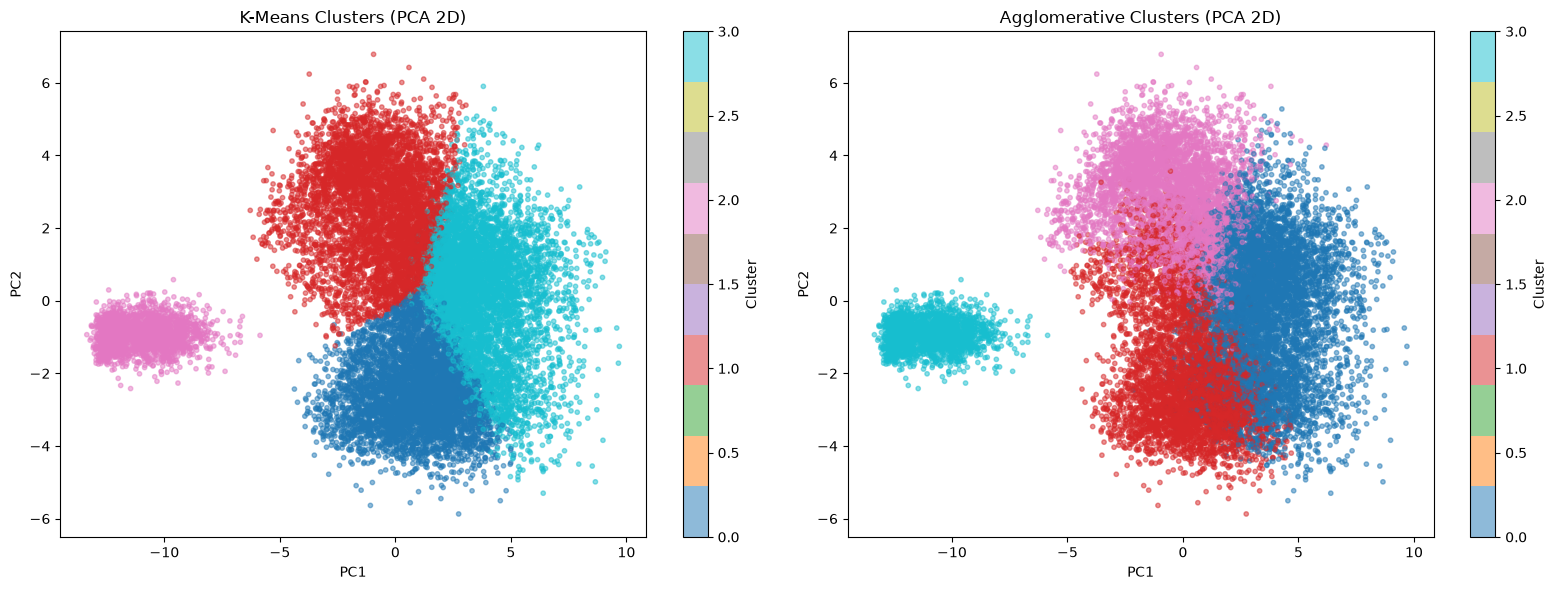

In [10]:
# PCA to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_kmeans, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (PCA 2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_agglo, cmap='tab10', alpha=0.5, s=10)
axes[1].set_title('Agglomerative Clusters (PCA 2D)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('clustering_pca_visualization.png', bbox_inches='tight')
plt.show()

### PCA Cluster Visualization
The first 2 principal components explain 75.0% of total variance (PC1: 59.5%, PC2: 15.5%), 
so this 2D projection captures most of the structure in the original 35-dimensional feature 
space. Both algorithms clearly isolate one small, well-separated cluster (bottom-left, pink) 
— almost certainly the Goalkeeper group, given their skill profile is fundamentally distinct 
from outfield players. Among the remaining clusters, K-Means shows a visibly cleaner boundary 
between its two outfield clusters than Agglomerative's, consistent with K-Means' stronger 
evaluation metrics above.

In [13]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_cluster_scaled)

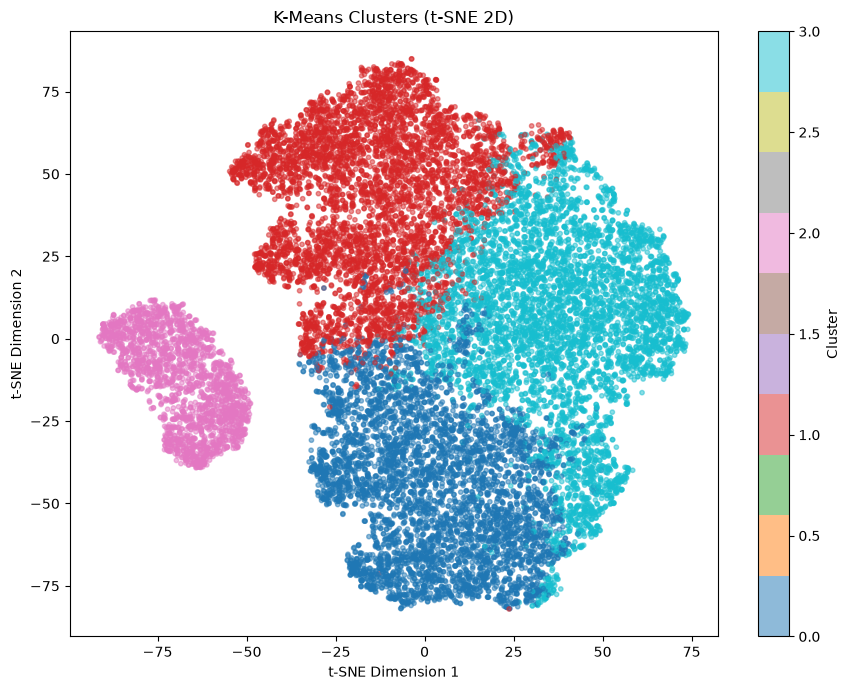

In [14]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels_kmeans, cmap='tab10', alpha=0.5, s=10)
plt.title('K-Means Clusters (t-SNE 2D)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('clustering_tsne_visualization.png', bbox_inches='tight')
plt.show()

### t-SNE Cluster Visualization
t-SNE (perplexity=30) reveals even clearer local separation than PCA, particularly for the 
Goalkeeper cluster (pink), which forms a completely isolated, tight grouping with no overlap 
into other clusters — reinforcing that goalkeepers are structurally distinct from outfield 
players purely based on skill attributes. The outfield clusters show more intertwined 
boundaries, consistent with the earlier finding that outfield positions (particularly 
midfielders) share overlapping skill profiles with adjacent roles. t-SNE's non-linear 
dimensionality reduction preserves local neighborhood structure better than PCA, at the cost 
of not preserving global distances between clusters.

In [16]:
crosstab_km = pd.crosstab(df['kmeans_cluster'], df['position_group'])
print("K-Means Cluster vs Position Group:\n", crosstab_km)

print("\n")

crosstab_ag = pd.crosstab(df['agglo_cluster'], df['position_group'])
print("Agglomerative Cluster vs Position Group:\n", crosstab_ag)

K-Means Cluster vs Position Group:
 position_group  Defender  Forward  Goalkeeper  Midfielder
kmeans_cluster                                           
0                    110     2724           0        2235
1                   4390       14           0         944
2                      0        0        2033           0
3                   1643      700           0        3457


Agglomerative Cluster vs Position Group:
 position_group  Defender  Forward  Goalkeeper  Midfielder
agglo_cluster                                            
0                   1402     1761           0        3641
1                    944     1669           0        2361
2                   3797        8           0         634
3                      0        0        2033           0


In [ ]:
S